<a href="https://colab.research.google.com/github/dee1empire/-ITAI-1371-ML-Labs-/blob/main/Copy_of_L09_DeloresBledsoe_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Create and train a single Dicision Tree
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

# Make predictions and evaluate its accuracy
y_pred = single_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred)

print(f"Accuracy of a single Decision Tree: {accuracy_tree:.2%}")


Accuracy of a single Decision Tree: 100.00%


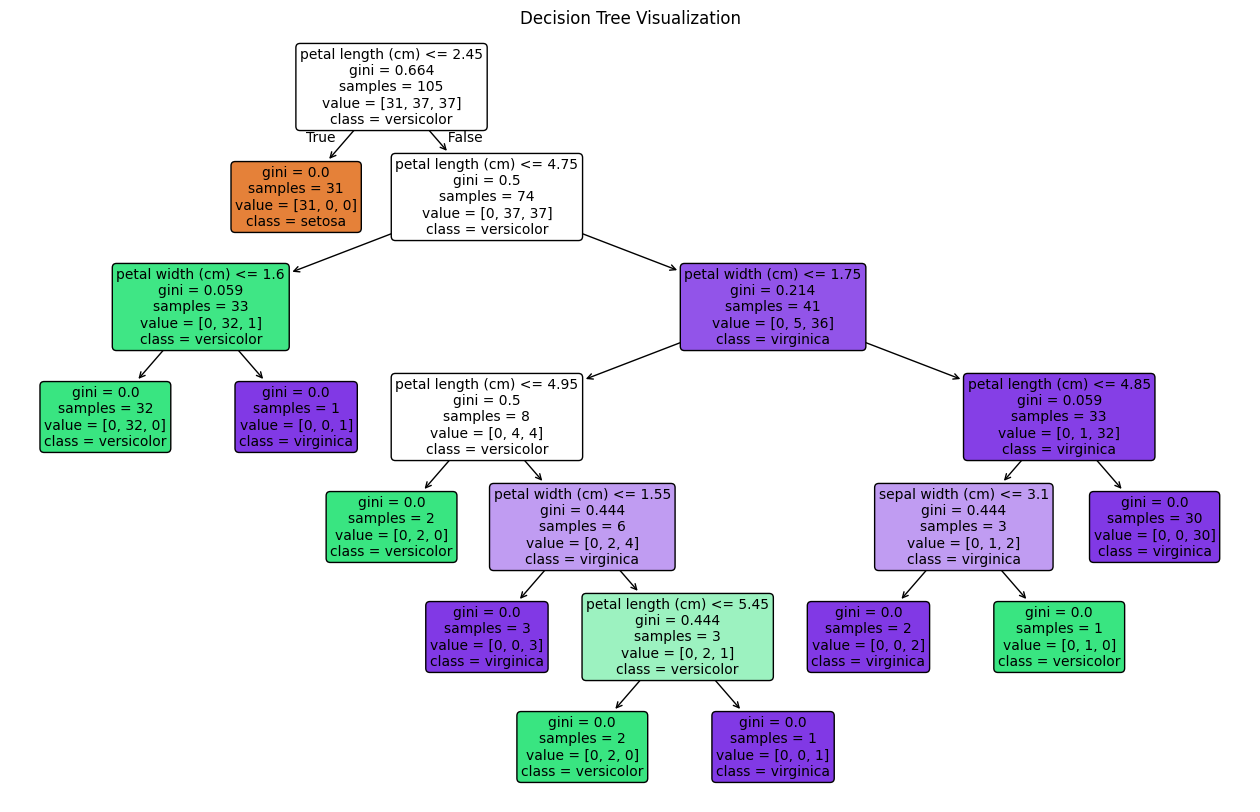

In [ ]:
# Visualize the trained Decision Tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
tree.plot_tree(
    single_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
# Create and train a Random Forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Make predictions and evaluate its accuracy
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of the Random Forest: {accuracy_rf:.2%}")

Accuracy of the Random Forest: 100.00%


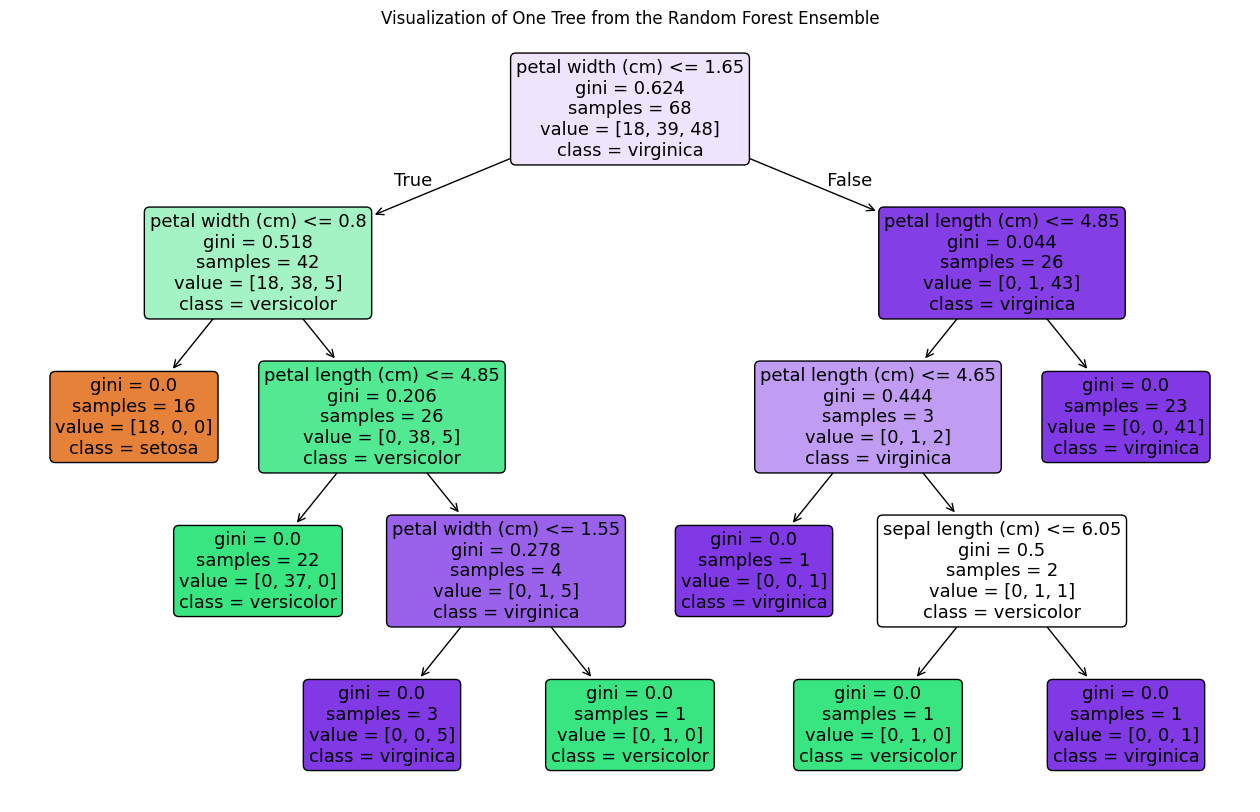

In [ ]:
# Visualize one tree inside the Random Forest Ensemble
from sklearn import tree
import matplotlib.pyplot as plt

# Select one tree from the Random Forest (the first estimator)
one_tree_in_forest = random_forest.estimators_[0]

plt.figure(figsize=(16, 10))
tree.plot_tree(
    one_tree_in_forest,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True)

plt.title("Visualization of One Tree from the Random Forest Ensemble")
plt.show()

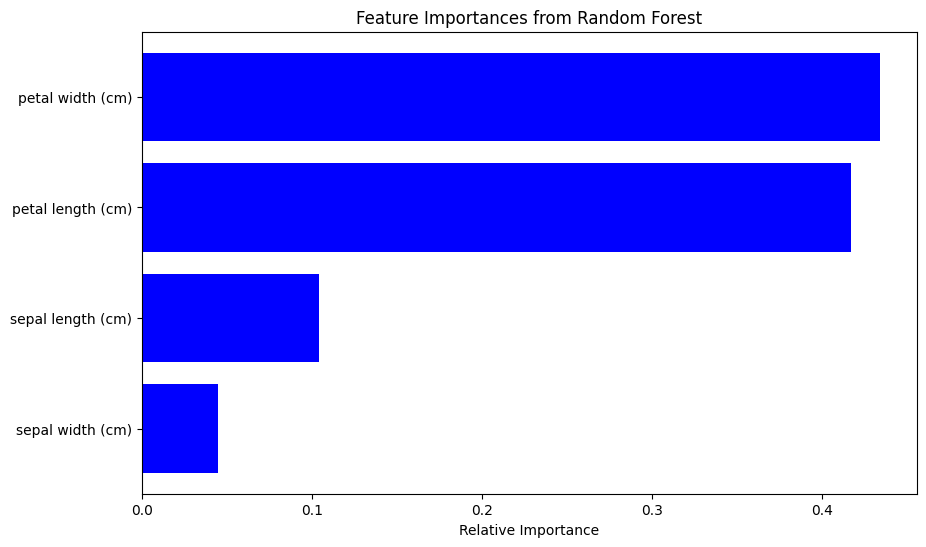

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the feature importances from the trained Random Forest model
importances = random_forest.feature_importances_

# Create a bar plot to visualize them
feature_names = iris.feature_names
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances from Random Forest")
plt.barh(range(len(indices)), importances[indices], color='b', align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

                                  **KNOWLEDGE CHECK**


1. In your own words, what is the main idea behind ensemble methods? Why is a \"committee\" of models often better than a single expert model?

*** The main idea is that a group of models working together has the capacity to make better decisions than a single one. Each model may have their own mistakes, but in the end, the final answer is usually more accurate.It is like asking 1000 people about a venue as aposed to asking just one.



2. Which model performed better in this lab, the single Decision Tree or the Random Forest? Is this what you expected? Why?

*** The Random Forest was the obvious winner for me. Yes, this is what I expected based on it is using many trees as opposed to using just one. Therefore, by averaging their predictions, it avoids overfitting and becomes more stable and accurate at the same time.



3. Looking at the feature importance plot, which two features were most important for classifying the iris flowers? Does this match what you might expect from your own knowledge of flowers?

*** For me, the most important features were petal length and petal width. It is logical to me this way because the different iris species have distinct different petal sizes, therefore, the measurements helped set them apart from one another.